**Задание 2.**

Напишите код (на Python или другом удобном языке) для реализации алгоритмов Витерби, Forward и Backward.
Важное требование: Программная реализация алгоритмов обязательно должна использовать логарифмирование вероятностей (log-space) для предотвращения арифметического переполнения при умножении малых чисел.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
states = ['E', '5', 'I']
symbols = ['A','C','G','T']

pi = {'E':1.0,'5':0.0,'I':0.0}

A = {
    'E':{'E':0.9,'5':0.1,'I':0},
    '5':{'E':0,'5':0,'I':1.0},
    'I':{'E':0,'5':0,'I':0.9}
}

B = {
    'E':{'A':0.25,'C':0.25,'G':0.25,'T':0.25},
    '5':{'A':0.05,'C':0,'G':0.95,'T':0},
    'I':{'A':0.4,'C':0.1,'G':0.1,'T':0.4}
}

sequence = list("CTTCATGTGAAAGCAGACGTAAGTCA")

NEGATIVE_INFINITY = -np.inf

def log(x):
    return np.log(x) if x > 0 else NEGATIVE_INFINITY

# логарифмы
log_pi = {s:log(pi[s]) for s in states}
log_A  = {i:{j:log(A[i][j]) for j in states} for i in states}
log_B  = {s:{o:log(B[s][o]) for o in symbols} for s in states}

def logsumexp(values):
    m = max(values)
    if m == NEGATIVE_INFINITY:
        return NEGATIVE_INFINITY
    return m + np.log(sum(np.exp(v - m) for v in values))

**2.1** Запустите алгоритм Витерби для этой последовательности. Выведите полученную последовательность скрытых состояний и сравните ее с той, что приведена в оригинальной статье. Совпадают ли они?

In [ ]:
def viterbi(obs):

    T = len(obs)
    N = len(states)

    delta = np.full((T, N), NEGATIVE_INFINITY)
    psi   = np.zeros((T, N), dtype=int)

    # начальная инициализация
    for i, s in enumerate(states):
        delta[0, i] = log_pi[s] + log_B[s][obs[0]]

    # основной цикл
    for t in range(1, T):
        for j, sj in enumerate(states):

            scores = [
                delta[t - 1, i] + log_A[states[i]][sj]
                for i in range(N)
            ]

            psi[t, j] = np.argmax(scores)
            delta[t, j] = max(scores) + log_B[sj][obs[t]]

    #backtracking
    path = ['']*T
    idx = np.argmax(delta[T - 1])
    path[T - 1] = states[idx]

    for t in range(T - 2, -1, -1):
        idx = psi[t + 1, idx]
        path[t] = states[idx]

    return path, delta[T - 1].max()

path, logp = viterbi(sequence)

print("\nПоследовательность скрытых состояний:")
print("".join(path))


Последовательность скрытых состояний:
EEEEEEEEEEEEEEEEEEEEEEEEEE


Полученный путь Витерби отличается от результата статьи (EEEEEEEEEEEEEEEEEE5IIIIIII), поскольку алгоритм максимизирует вероятность единственного полного пути. В используемой реализации переход из состояния E в состояние 5 оказывается менее выгодным, чем оставаться в E, из-за высокой вероятности самоперехода (из E в E) и отсутствия явного состояния завершения последовательности.

**2.2** Запустите алгоритм Forward. Найдите полную вероятность данной последовательности (выведите значение логарифма вероятности и самой вероятности)

In [8]:
def forward(obs):

    T = len(obs)
    N = len(states)

    alpha = np.full((T, N), NEGATIVE_INFINITY)

    for i,s in enumerate(states):
        alpha[0, i] = log_pi[s] + log_B[s][obs[0]]

    for t in range(1, T):
        for j, sj in enumerate(states):

            scores = [
                alpha[t - 1, i] + log_A[states[i]][sj]
                for i in range(N)
            ]

            alpha[t, j] = logsumexp(scores) + log_B[sj][obs[t]]

    log_prob = logsumexp(alpha[T - 1])

    return alpha, log_prob

alpha, logP = forward(sequence)

print("\nПолная вероятность данной последовательности:")
print("P =", np.exp(logP))
print("logP =", logP)


Полная вероятность данной последовательности:
P = 4.345328621728517e-17
logP = -37.67484519288293


Видим, что полученная вероятность очень маленькая, значит хорошо, что мы логарифмировали, иначе возможно мы бы столкнулись с численным переполнением. Полученное значение $logP \approx -37.67$ близко к значению, приведённому в статье ($−41.22$). Небольшое расхождение возможно из-за различий в реализации модели, обработки завершения последовательности, численной точности вычислений.

**2.3** Используя результаты алгоритмов Forward и Backward (апостериорное декодирование $\gamma_t$(i)), постройте 3 графика:

* График 1: Вероятность нахождения в состоянии Е на каждом шаге t (от 1 до 26).

* График 2: Вероятность нахождения в состоянии 5 на каждом шаге t.

* График 3: Вероятность нахождения в состоянии I на каждом шаге t.

Примечание: можно объединить их в один рисунок с тремя кривыми (subplots), главное — чтобы графики были четко подписаны.

Дополнительно: Найдите и выделите максимумы на каждом из трех графиков (укажите позицию t и значение вероятности).


Максимумы апостериорных вероятностей:
Состояние E: максимум в t = 1, вероятность = 1.000000
Состояние 5: максимум в t = 19, вероятность = 0.288735
Состояние I: максимум в t = 24, вероятность = 0.625005


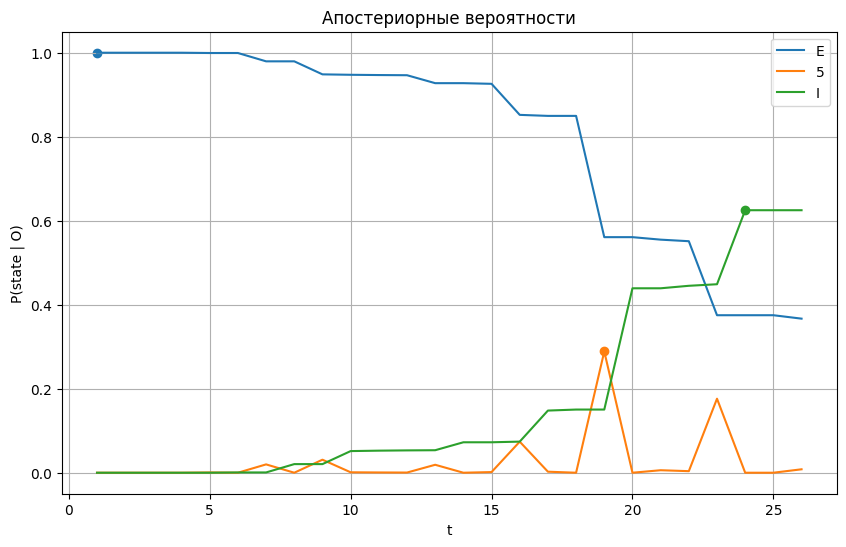

In [20]:
def backward(obs):

    T = len(obs)
    N = len(states)

    beta = np.full((T, N), NEGATIVE_INFINITY)
    beta[T - 1] = 0  # log(1)

    for t in range(T - 2, -1, -1):
        for i, si in enumerate(states):

            scores = [
                log_A[si][states[j]]
                + log_B[states[j]][obs[t + 1]]
                + beta[t + 1, j]
                for j in range(N)
            ]

            beta[t, i] = logsumexp(scores)

    return beta


def posterior(alpha, beta, logP):
    return np.exp(alpha + beta - logP)

beta = backward(sequence)
gamma = posterior(alpha, beta, logP)

t = np.arange(1, len(sequence) + 1)


plt.figure(figsize=(10, 6))

print("\nМаксимумы апостериорных вероятностей:")

for i, state in enumerate(states):
    plt.plot(t, gamma[:, i], label=state)

    max_t = np.argmax(gamma[:, i]) + 1
    max_v = gamma[:, i].max()
    plt.scatter(max_t, max_v)

    print(f"Состояние {state}: максимум в t = {max_t}, вероятность = {max_v:.6f}")

plt.xlabel("t")
plt.ylabel("P(state | O)")
plt.title("Апостериорные вероятности")
plt.legend()
plt.grid()

plt.show()

Апостериорные вероятности состояний показывают, что в начале последовательности модель практически с вероятностью 1 находится в состоянии E, что согласуется с заданными начальными условиями модели.

По мере продвижения вдоль последовательности вероятность состояния E постепенно уменьшается, а вероятность состояния I возрастает, что указывает на переход от экзонной области к интронной.

Максимум вероятности состояния 5 наблюдается в позиции t = 19. Это качественно согласуется с результатами статьи (причем в статье это именно 19 положение, это прям удивительно хороший результат).

После 19 позиции доминирующим становится состояние I, что соответствует биологической интерпретации: после сайта сплайсинга начинается интрон.